epoch=0,loss=2.224538,acc=0.2500
epoch=200,loss=0.000593,acc=1.0000
epoch=400,loss=0.000150,acc=1.0000
epoch=600,loss=0.000057,acc=1.0000
epoch=800,loss=0.000026,acc=1.0000
epoch=1000,loss=0.000015,acc=1.0000
epoch=1200,loss=0.000009,acc=1.0000
epoch=1400,loss=0.000006,acc=1.0000
epoch=1600,loss=0.000004,acc=1.0000
epoch=1800,loss=0.000003,acc=1.0000
last loss 2.4109427221922378e-06
預測 [0 1 2 1]
實際 [0 1 2 1]


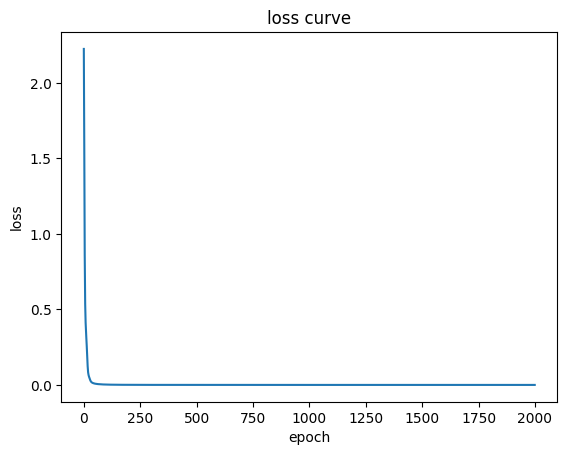

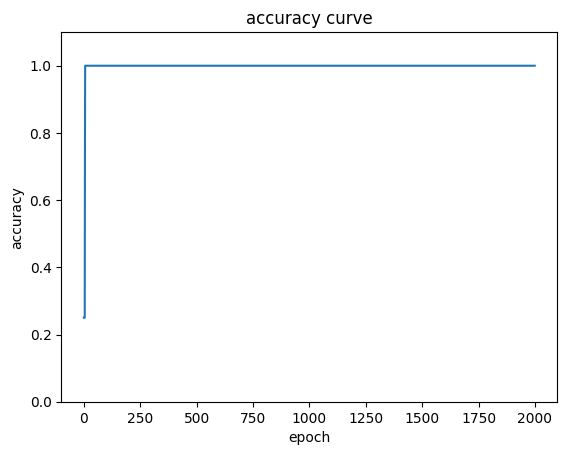

In [16]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
X=np.array([
    [1,2],
    [2,1],
    [3,4],
    [4,3]
])
y_label=np.array([0,1,2,1])
Y=np.zeros((4,3))
Y[np.arange(4),y_label]=1
layers=[2,16,16,8,3]
lr=0.01
epochs=2000
eps=1e-8
batch_size=2
beta1=0.9
beta2=0.999
def relu(z):
    return np.maximum(0,z)
def back_relu(dA,Z):
    dZ=dA.copy()
    dZ[Z<=0]=0
    return dZ
def softmax(z):
    exp_z=np.exp(z-np.max(z,axis=1,keepdims=True))
    return exp_z/np.sum(exp_z,axis=1,keepdims=True)
def loss_fn(Y,y_pred):
    return -np.mean(np.sum(Y*np.log(y_pred+eps),axis=1))
def create_model(layers):
    np.random.seed(42)
    params=[]
    for i in range(len(layers)-1):
        fan_in=layers[i]
        fan_out=layers[i+1]
        w=np.random.randn(fan_in,fan_out)*np.sqrt(2/fan_in)
        b=np.zeros((1,fan_out))
        vw=np.zeros_like(w)
        vb=np.zeros_like(b)
        sw=np.zeros_like(w)
        sb=np.zeros_like(b)
        params.append({
            "w":w,"b":b,
            "vw":vw,"vb":vb,
            "sw":sw,"sb":sb
        })
    model={
        "params":params,
        "caches":None
    }    
    return model
def forward(model,X_batch):
    params=model["params"]
    caches=[]
    A=X_batch
    for i,layer in enumerate(params):
        w=layer["w"]
        b=layer["b"]
        A_prev=A
        Z=A_prev@w+b
        if i < len(params)-1:
            A=relu(Z)
        else:
            A=softmax(Z)
        caches.append({"A_prev":A_prev,"Z":Z})
    model["caches"]=caches
    return A
def backward(model,Y_batch,y_pred):
    params=model["params"]
    caches=model["caches"]
    L=len(params)
    grads=[None]*L
    n=Y_batch.shape[0]
    dA=None
    for i in reversed(range(L)):
        w=params[i]["w"]
        cach=caches[i]
        A_prev=cach["A_prev"]
        Z=cach["Z"]
        if i == L-1:
            dZ=y_pred-Y_batch
        else:
            dZ=back_relu(dA,Z)
        dw=A_prev.T@dZ/n
        db=np.mean(dZ,axis=0,keepdims=True)
        dA=dZ@w.T
        grads[i]={"dw":dw,"db":db}
    return grads
def update(model,grads,lr,t,beta1=0.9,beta2=0.999):
    params=model["params"]
    for i in range(len(params)):
        dw=grads[i]["dw"]
        db=grads[i]["db"]

        vw=params[i]["vw"]
        vb=params[i]["vb"]
        sw=params[i]["sw"]
        sb=params[i]["sb"]

        vw=beta1*vw+(1-beta1)*dw
        vb=beta1*vb+(1-beta1)*db

        sw=beta2*sw+(1-beta2)*(dw**2)
        sb=beta2*sb+(1-beta2)*(db**2)

        vw_corr=vw/(1-beta1**t)
        vb_corr=vb/(1-beta1**t)
        sw_corr=sw/(1-beta2**t)
        sb_corr=sb/(1-beta2**t)
        #回存回去
        params[i]["vw"]=vw
        params[i]["vb"]=vb
        params[i]["sw"]=sw
        params[i]["sb"]=sb

        params[i]["w"]-=lr*vw_corr/(np.sqrt(sw_corr)+eps)
        params[i]["b"]-=lr*vb_corr/(np.sqrt(sb_corr)+eps)
def train(model,X,Y,lr,epochs,batch_size):
    losses=[]
    accs=[]
    t=0
    n=X.shape[0]
    for epoch in range(epochs):
        indices=np.random.permutation(n)
        X_shuf=X[indices]
        Y_shuf=Y[indices]
        for i in range(0,n,batch_size):
            t+=1
            X_batch=X_shuf[i:i+batch_size]
            Y_batch=Y_shuf[i:i+batch_size]
            y_pred_batch=forward(model,X_batch)
            grads=backward(model,Y_batch,y_pred_batch)
            update(model,grads,lr,t,beta1=0.9,beta2=0.999)
        y_pred_full=forward(model,X)
        loss=loss_fn(Y,y_pred_full)
        losses.append(loss)
        y_pred_label=np.argmax(y_pred_full,axis=1)
        acc=np.mean(y_pred_label == y_label)
        accs.append(acc)
        if epoch % 200 == 0:
            print(f"epoch={epoch},loss={loss:.6f},acc={acc:.4f}")
    return losses,accs
def predict(model,X):
    y_pred=forward(model,X)
    return np.argmax(y_pred,axis=1)
model=create_model(layers)
losses,accs=train(model,X,Y,lr,epochs,batch_size)
pred=predict(model,X)
print("last loss",losses[-1])
print("預測",pred)
print("實際",y_label)
plt.plot(losses)
plt.title("loss curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.plot(accs)
plt.title("accuracy curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0,1.1)
plt.show()